In [1]:
from typing import Union, List

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import median_abs_deviation

from Pipeline.Global.PlottingData import PlottingData

In [2]:
def get_clean_mask(data: Union[pd.Series, np.ndarray], threshold: float = 3.5) -> Union[pd.Series, np.ndarray]:
    median = np.median(data)
    mad = median_abs_deviation(data, scale='normal')

    if mad == 0:
        if isinstance(data, pd.Series):
            return pd.Series(True, index=data.index)
        return np.ones(len(data), dtype=bool)

    modified_z_score = 0.6745 * (data - median) / mad

    mask = np.abs(modified_z_score) < threshold

    return mask

In [3]:
def get_limits(data, sigma=3.5, min_floor=0.5, reference_col=None, cv_floor=0.015):
    """
    Calculates a ROBUST SYMMETRIC limit.
    Hybrid Mode: Supports both FIXED floors (e.g., 0.5 kg) and DYNAMIC floors (e.g., 1.5% of TBW).

    Args:
    - data (Series): The error/difference column.
    - sigma (float): Outlier threshold (default 3.5).
    - min_floor (float): The default HARD floor (used if reference_col is None).
    - reference_col (Series, Optional): The magnitude column (e.g., TBW).
      If provided, the floor becomes dynamic (Mean of Ref * cv_floor).
    - cv_floor (float): The percentage noise floor (default 1.5% = 0.015).
    """
    # 1. Clean Data (Drop NaNs)
    clean_data = data.dropna()

    # 2. Calculate Statistical Limit (MAD)
    # This captures the natural spread of your specific dataset
    mad = stats.median_abs_deviation(clean_data, scale=1.4826)
    stat_limit = sigma * mad

    # 3. Determine the Floor Strategy
    if reference_col is not None:
        # [DYNAMIC MODE] Floor = % of the Reference Magnitude
        # Align reference to clean_data indices to avoid size mismatch
        ref_clean = reference_col.loc[clean_data.index]
        floor_val = ref_clean.abs().median() * cv_floor
    else:
        # [STATIC MODE] Floor = Fixed Number (Backwards Compatible)
        floor_val = min_floor

    # 4. Final Limit: The Greater of the Two
    # Prevents collapse on perfect data, but respects physics on noisy data.
    return max(stat_limit, floor_val)

In [4]:
def get_95_mask(df: pd.DataFrame, cols: List[str]) -> pd.Series:

    q_low = df[cols].quantile(0.025)
    q_high = df[cols].quantile(0.975)

    mask = ((df[cols] >= q_low) & (df[cols] <= q_high)).all(axis=1)

    return mask

In [5]:
filePath = '../../Storage/Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)
df_raw = df.copy()

In [6]:
BMI_Outliers = get_clean_mask(df['Body Mass Index (BMI)'] - (df['Weight'] / ((df['Height'] / 100) ** 2)) )
df['Body Mass Index (BMI)'] = np.where(BMI_Outliers,df['Body Mass Index (BMI)'],(df['Weight'] / ((df['Height'] / 100) ** 2)) )

In [7]:
df.loc[df['Obesity (%)'] == 1954, 'Obesity (%)'] = 19.54

In [8]:
# Track A: Physics (Summation) | TBW - (ECW + ICW)
df['TBW_disc_sum'] = df['Total Body Water (TBW)'] - (df['Extracellular Water (ECW)'] + df['Intracellular Water (ICW)'])
TBW_disc_sum_lim_val = get_limits(df['TBW_disc_sum'],reference_col=df['Total Body Water (TBW)'])
TBW_disc_fit_sum_lim = df['TBW_disc_sum'].abs() < TBW_disc_sum_lim_val

# Track B: Logic (Ratio) | TBW - (100 * ECW/Ratio)
df['TBW_disc_ratio'] = df['Total Body Water (TBW)'] - (100 * df['Extracellular Water (ECW)'] / df['Extracellular Fluid/Total Body Water (ECF/TBW)'])
TBW_disc_ratio_lim_val = get_limits(df['TBW_disc_ratio'],reference_col=df['Total Body Water (TBW)'])
TBW_disc_fit_ratio_lim = (df['TBW_disc_ratio'].abs() < TBW_disc_ratio_lim_val)

# Track C : Sum Of Ratio | 100 - ( ECF/TBW + ICF/TBW )
df['TBW_disc_sumOfRatio'] = 100 - (df['Extracellular Fluid/Total Body Water (ECF/TBW)'] + (df['Intracellular Water (ICW)'] / df['Total Body Water (TBW)'] * 100))
TBW_disc_sumOfRatio_lim_val = get_limits(df['TBW_disc_sumOfRatio'])
TBW_disc_fit_sumOfRatio_lim = (df['TBW_disc_sumOfRatio'].abs() < TBW_disc_sumOfRatio_lim_val)

# Track D : Different of Track A and Track B | (ECW + ICW) - (100 * ECW/Ratio)
df['TBW_disc_sumOfCalc'] = (df['Total Body Water (TBW)'] - (df['Extracellular Water (ECW)'] + df['Intracellular Water (ICW)'])) - (df['Total Body Water (TBW)'] - (100 * df['Extracellular Water (ECW)'] / df['Extracellular Fluid/Total Body Water (ECF/TBW)']))
TBW_disc_sumOfCalc_lim_val = get_limits(df['TBW_disc_sumOfCalc'])
TBW_disc_fit_sumOfCalc_lim = (df['TBW_disc_sumOfCalc'].abs() < TBW_disc_sumOfCalc_lim_val)

In [9]:
df_tbw_raw = df.copy()
# Case 1 : Track A True : TBW, ECW and ICW are True, ECF/TBW is False
# Rec : ECF/TBW = ECW/TBW * 100
fix_ECF_mask = TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim
df.loc[fix_ECF_mask, 'Extracellular Fluid/Total Body Water (ECF/TBW)'] = (df['Extracellular Water (ECW)'] / df['Total Body Water (TBW)']) * 100

# Case 2 : Track B True : TBW, ECW and ECF/TBW are True, ICW is False
# Rec : ICW = TBW - ECW
fix_ICW_mask = TBW_disc_fit_ratio_lim & ~TBW_disc_fit_sum_lim
df.loc[fix_ICW_mask, 'Intracellular Water (ICW)'] = df['Total Body Water (TBW)'] - df['Extracellular Water (ECW)']

# Case 3 : Track C True : ECF/TBW, ICW and TBW are True, ECW is False
# Rec : ECW = TBW - ICW
fix_ECW_mask = TBW_disc_fit_sumOfRatio_lim & ~TBW_disc_fit_sum_lim
df.loc[fix_ECW_mask, 'Extracellular Water (ECW)'] = df['Total Body Water (TBW)'] - df['Intracellular Water (ICW)']

# Case 4 : Track D True : ECW, ICW and ECF/TBW are True, TBW is False
# Rec : TBW = ECW + ICW
fix_TBW_mask = TBW_disc_fit_sumOfCalc_lim & ~TBW_disc_fit_sum_lim
df.loc[fix_TBW_mask, 'Total Body Water (TBW)'] = df['Extracellular Water (ECW)'] + df['Intracellular Water (ICW)']

# Case 5 : Fail All Body Water Track : Multiple columns are false
body_water_multi_mask = ~TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim & ~TBW_disc_fit_sumOfRatio_lim & ~TBW_disc_fit_sumOfCalc_lim

In [10]:
df['TBW_disc_sum'] = df['Total Body Water (TBW)'] - (df['Extracellular Water (ECW)'] + df['Intracellular Water (ICW)'])
df['TBW_disc_ratio'] = df['Total Body Water (TBW)'] - (100 * df['Extracellular Water (ECW)'] / df['Extracellular Fluid/Total Body Water (ECF/TBW)'])
df['TBW_disc_sumOfCalc'] = (df['Total Body Water (TBW)'] - (df['Extracellular Water (ECW)'] + df['Intracellular Water (ICW)'])) - (df['Total Body Water (TBW)'] - (100 * df['Extracellular Water (ECW)'] / df['Extracellular Fluid/Total Body Water (ECF/TBW)']))
track_config = {
    'title': "Body Water Recovery: Physics Limits Projection",
    'x_col': 'TBW_disc_sum',
    'y_col': 'TBW_disc_ratio',
    'lim_a': TBW_disc_sum_lim_val,
    'lim_b': TBW_disc_ratio_lim_val,
    'lim_d': TBW_disc_sumOfCalc_lim_val
}

In [11]:
# Track E : Lean Fat Summation | TFC - (Weight - (Weight * LM / 100))
df['TFC_disc_lean'] = df['Total Fat Content (TFC)'] - ( df['Weight'] - (df['Weight'] * df['Lean Mass (LM) (%)'] / 100))
TFC_disc_lean_lim_val = get_limits(df['TFC_disc_lean'],reference_col=df['Total Fat Content (TFC)'])
TFC_disc_fit_lean_lim = df['TFC_disc_lean'].abs() < TFC_disc_lean_lim_val

# Track F : Fat Content Ratio | TFC - (Weight * TBFR / 100)
df['TFC_disc_ratio'] = df['Total Fat Content (TFC)'] - (df['Weight'] * (df['Total Body Fat Ratio (TBFR) (%)'] / 100))
TFC_disc_ratio_lim_val = get_limits(df['TFC_disc_ratio'],reference_col=df['Total Fat Content (TFC)'])
TFC_disc_fit_ratio_lim  = (df['TFC_disc_ratio'].abs() < TFC_disc_ratio_lim_val)

# Track G : Lean Fat ratio Summation | 100 - (LM+TBFR)
df['TFC_disc_sumOfRatio'] = 100 - (df['Lean Mass (LM) (%)'] + df['Total Body Fat Ratio (TBFR) (%)'])
TFC_disc_sumOfRatio_lim_val = get_limits(df['TFC_disc_sumOfRatio'])
TFC_disc_fit_sumOfRatio_lim = (df['TFC_disc_sumOfRatio'].abs() < TFC_disc_sumOfRatio_lim_val)

In [12]:
df_tfc_raw = df.copy()
# Case 6 : Track E True : TFC and LM are True, TBFR is False
# Rec : TBFR = TFC / Weight * 100
fix_TBFR_mask = TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim
df.loc[fix_TBFR_mask, 'Total Body Fat Ratio (TBFR) (%)'] = (df['Total Fat Content (TFC)']/df['Weight']) * 100

# Case 7 : Track F True : TFC and TBFR are True, LM is False
# Rec : LM = 100 - TBFR
fix_LM_mask = TFC_disc_fit_ratio_lim & ~TFC_disc_fit_lean_lim
df.loc[fix_LM_mask, 'Lean Mass (LM) (%)'] = 100 - df['Total Body Fat Ratio (TBFR) (%)']

# Case 8 : Track G True : LM and TBFR are True, TFC or Weight is False
# Rec : TFC = Weight * TBFR / 100 ( Assume Height and Weight as ground truth )
fix_TFC_mask = TFC_disc_fit_sumOfRatio_lim & ~TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim
df.loc[fix_TFC_mask, 'Total Fat Content (TFC)'] = (df['Total Body Fat Ratio (TBFR) (%)'] * df['Weight']) / 100

# Case 9 : Fail All Body Fat Track
body_fat_multi_mask = ~TFC_disc_fit_sumOfRatio_lim & ~TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim

In [13]:
df['TFC_disc_lean'] = df['Total Fat Content (TFC)'] - ( df['Weight'] - (df['Weight'] * df['Lean Mass (LM) (%)'] / 100))
df['TFC_disc_ratio'] = df['Total Fat Content (TFC)'] - (df['Weight'] * (df['Total Body Fat Ratio (TBFR) (%)'] / 100))

fat_track_config = {
    'title': "Body Fat Recovery: Physics Limits Projection",
    'x_col': 'TFC_disc_lean',
    'y_col': 'TFC_disc_ratio',
    'lim_x': TFC_disc_lean_lim_val,
    'lim_y': TFC_disc_ratio_lim_val,

    'label_x': "Track E Deviation (Lean Logic) [Kg]",
    'label_y': "Track F Deviation (Ratio Logic) [Kg]"
}

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Data Figure\TFC_Fixed_.png


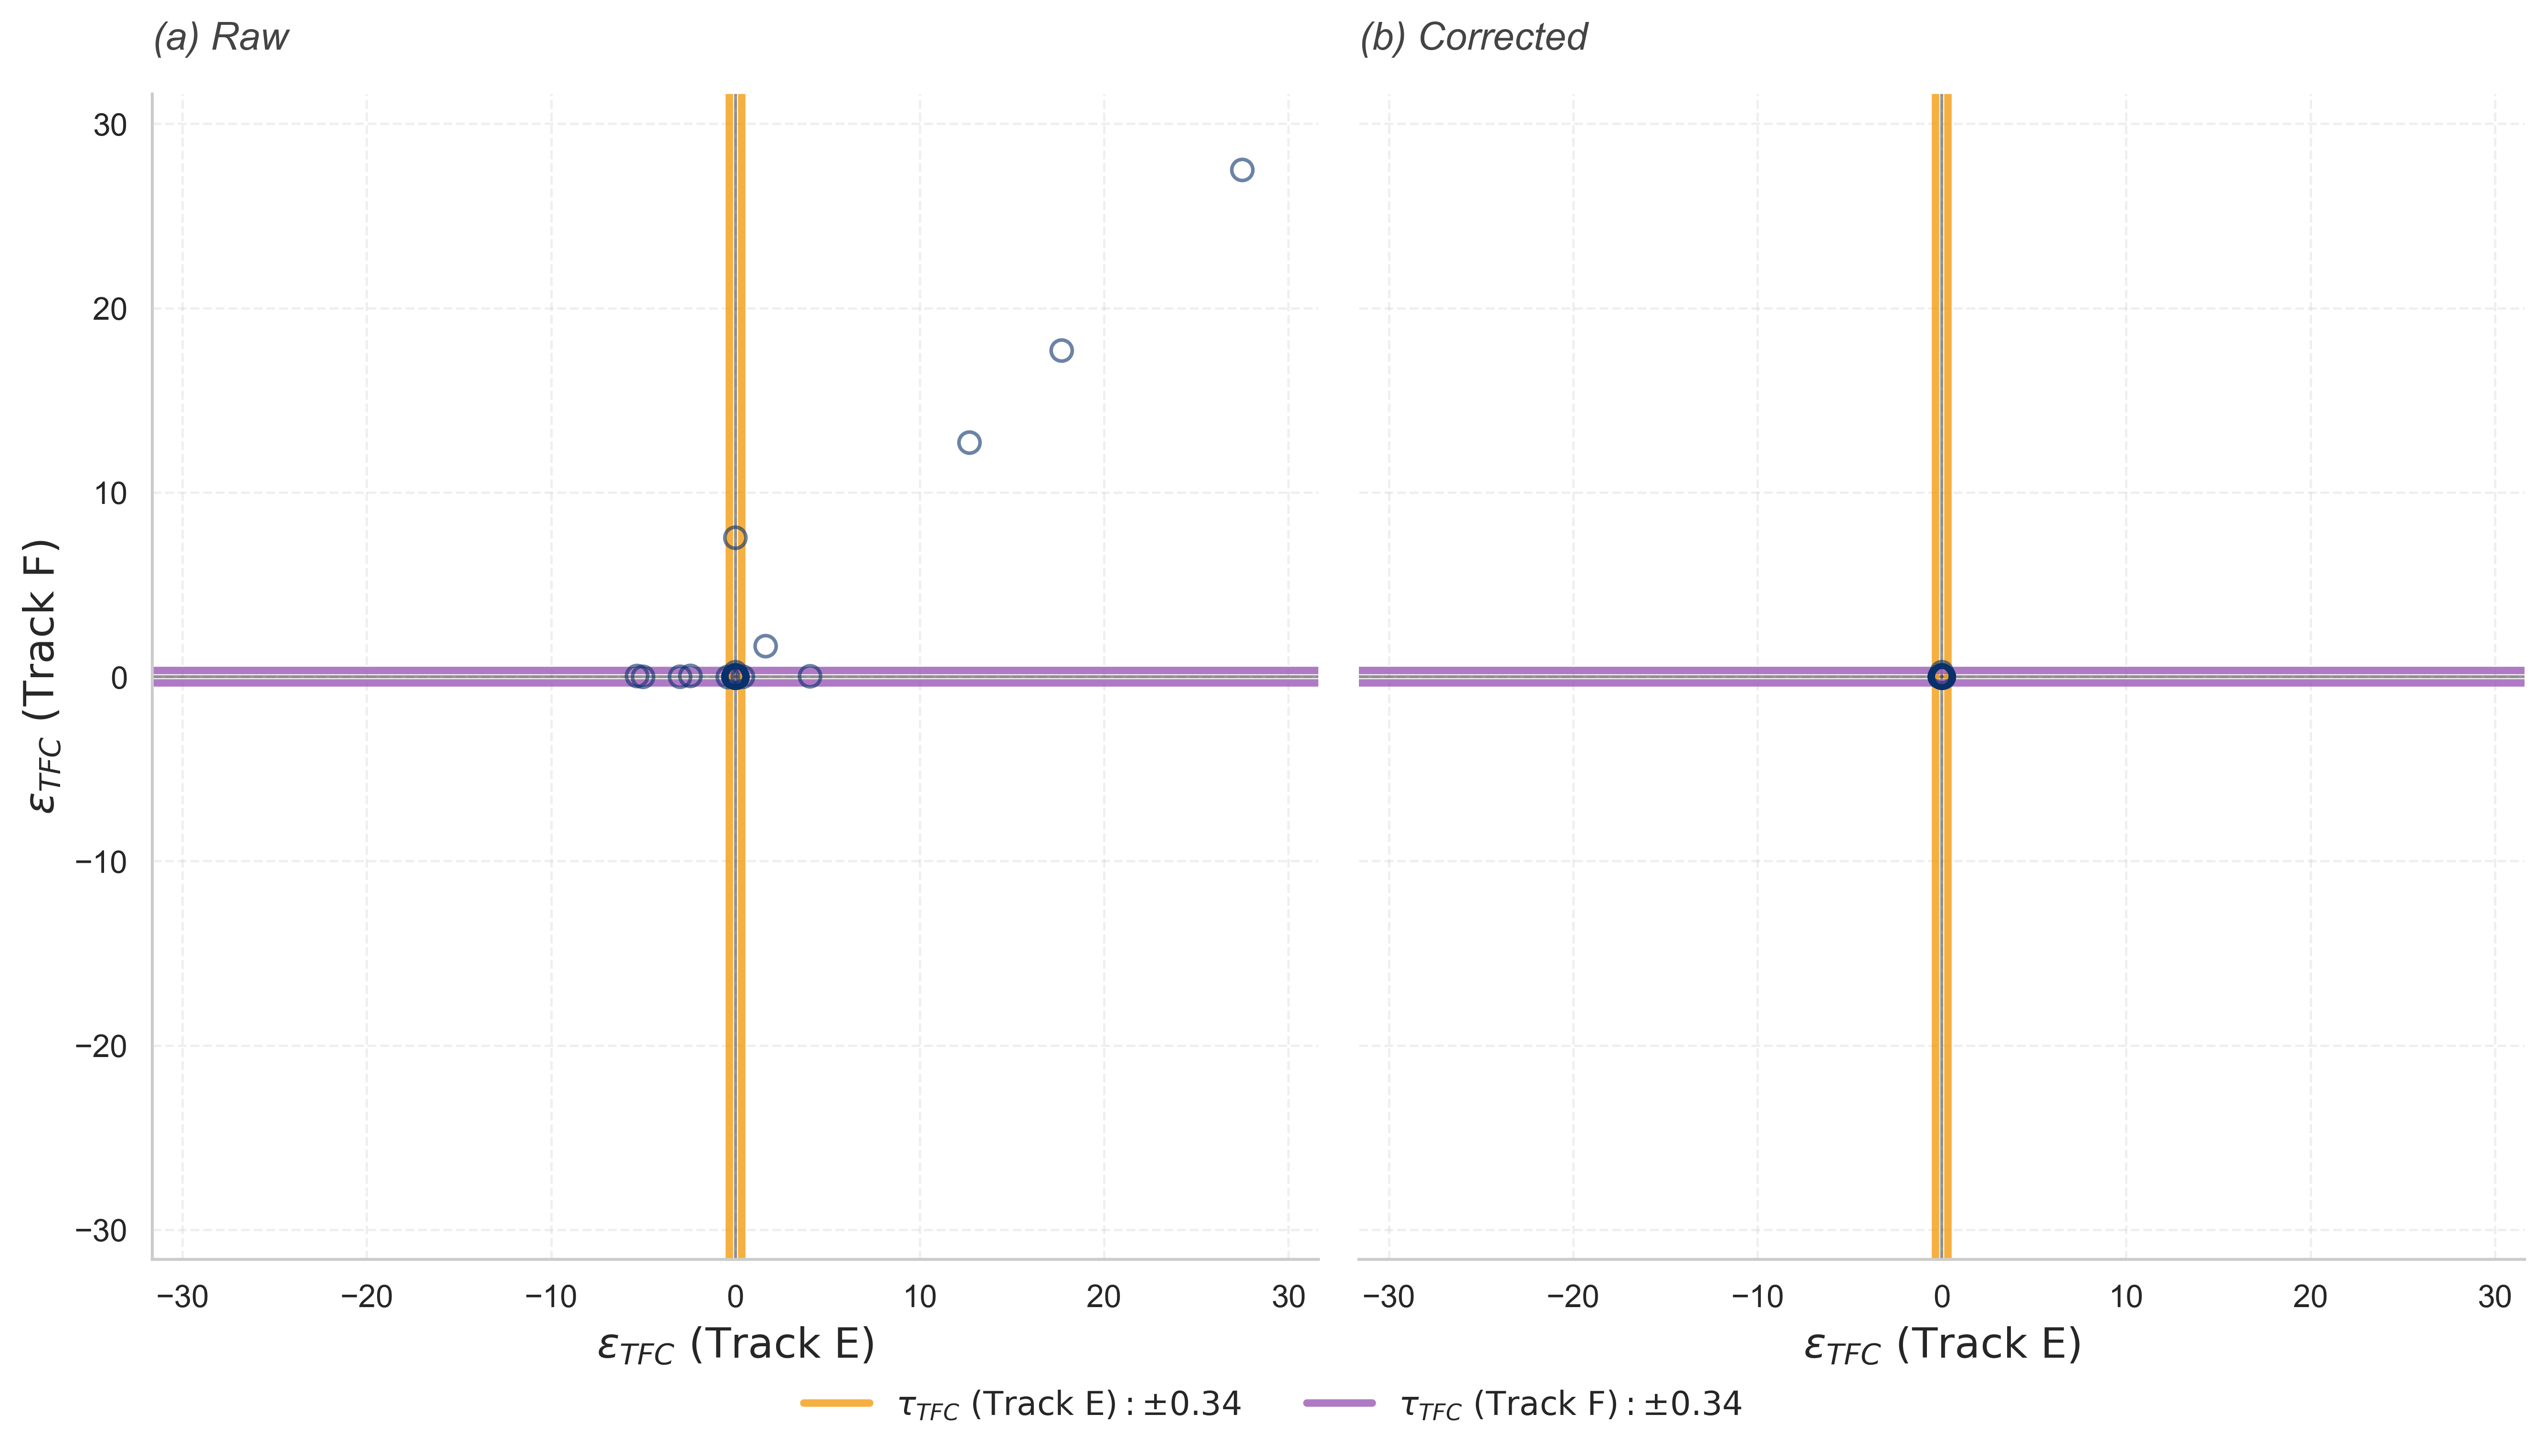

In [14]:
PlottingData.plot_2track_repair_impact(df_tfc_raw, df, fat_track_config,
                                       main_title="TFC Fixed",
                                       title_on  = False,
                                       is_final_record=True)

In [15]:
# Muscle mass / Total Protein ratio
df['Visceral Muscle - Muscle Ratio'] = df['Visceral Muscle Area (VMA) (Kg)']/df['Muscle Mass (MM)']
df['Protein - Muscle Ratio'] = (df['Weight'] * df['Body Protein Content (Protein) (%)']/100) / df['Muscle Mass (MM)']
df['Protein - Visceral Muscle Ratio'] = (df['Weight'] * df['Body Protein Content (Protein) (%)']/100) / df['Visceral Muscle Area (VMA) (Kg)']

muscle_outliers  = ~get_95_mask(df, ['Muscle Mass (MM)'])
visceral_outliers = ~get_95_mask(df, ['Visceral Muscle Area (VMA) (Kg)'])
protein_outliers    = ~get_95_mask(df, ['Body Protein Content (Protein) (%)'])
visceral_muscle_ratio_outliers  = ~get_95_mask(df, ['Visceral Muscle - Muscle Ratio'])
protein_muscle_ratio_outliers   = ~get_95_mask(df, ['Protein - Muscle Ratio'])
protein_visceral_ratio_outliers = ~get_95_mask(df, ['Protein - Visceral Muscle Ratio'])


vis_mus_ratio_median = df['Visceral Muscle - Muscle Ratio'].median()
pro_mus_ratio_median = df['Protein - Muscle Ratio'].median()
pro_vis_ratio_median = df['Protein - Visceral Muscle Ratio'].median()
df['Trace Element'] = df['Weight'] - (df['Total Body Water (TBW)'] + df['Total Fat Content (TFC)'] + (df['Weight'] * df['Body Protein Content (Protein) (%)']/100) + df['Bone Mass (BM)'])
trace_median = df['Trace Element'].median()

df_protein_raw = df.copy()
# Muscle Mass is False
# Rec :
muscle_mass_error = muscle_outliers & visceral_muscle_ratio_outliers & protein_muscle_ratio_outliers & ~protein_visceral_ratio_outliers

mus_target_vis = df.loc[muscle_mass_error, 'Visceral Muscle Area (VMA) (Kg)']
mus_target_weight = df.loc[muscle_mass_error, 'Weight']
mus_target_protein_pct = df.loc[muscle_mass_error, 'Body Protein Content (Protein) (%)']

mus_est_via_vma = mus_target_vis / vis_mus_ratio_median
mus_est_via_protein = (mus_target_weight * (mus_target_protein_pct / 100)) / pro_mus_ratio_median
df.loc[muscle_mass_error, 'Muscle Mass (MM)'] = (mus_est_via_vma + mus_est_via_protein) / 2


# Body Protein Content is False
body_protein_content_error = protein_outliers & ~visceral_muscle_ratio_outliers & protein_muscle_ratio_outliers & protein_visceral_ratio_outliers
pro_est_via_mm = df['Muscle Mass (MM)']*df['Protein - Muscle Ratio'].median()
pro_est_via_vma = df['Visceral Muscle Area (VMA) (Kg)']*df['Protein - Visceral Muscle Ratio'].median()
df.loc[body_protein_content_error, 'Body Protein Content (Protein) (%)'] = 100 * (pro_est_via_mm + pro_est_via_vma)/ (2*df['Weight'])

# Visceral Muscle Area is False
visceral_muscle_area_error = visceral_outliers & visceral_muscle_ratio_outliers & ~protein_muscle_ratio_outliers & protein_visceral_ratio_outliers
vis_target_mus = df.loc[visceral_muscle_area_error,'Muscle Mass (MM)']
vis_target_weight = df.loc[visceral_muscle_area_error,'Weight']
vis_target_protein_pct = df.loc[visceral_muscle_area_error, 'Body Protein Content (Protein) (%)']

vis_est_via_vma = vis_target_mus * vis_mus_ratio_median
vis_est_via_protein = (vis_target_weight * vis_target_protein_pct / 100) / pro_vis_ratio_median
df.loc[visceral_muscle_area_error, 'Visceral Muscle Area (VMA) (Kg)'] = (vis_est_via_vma + vis_est_via_protein) / 2

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Data Figure\Muscle_Fixed_.png


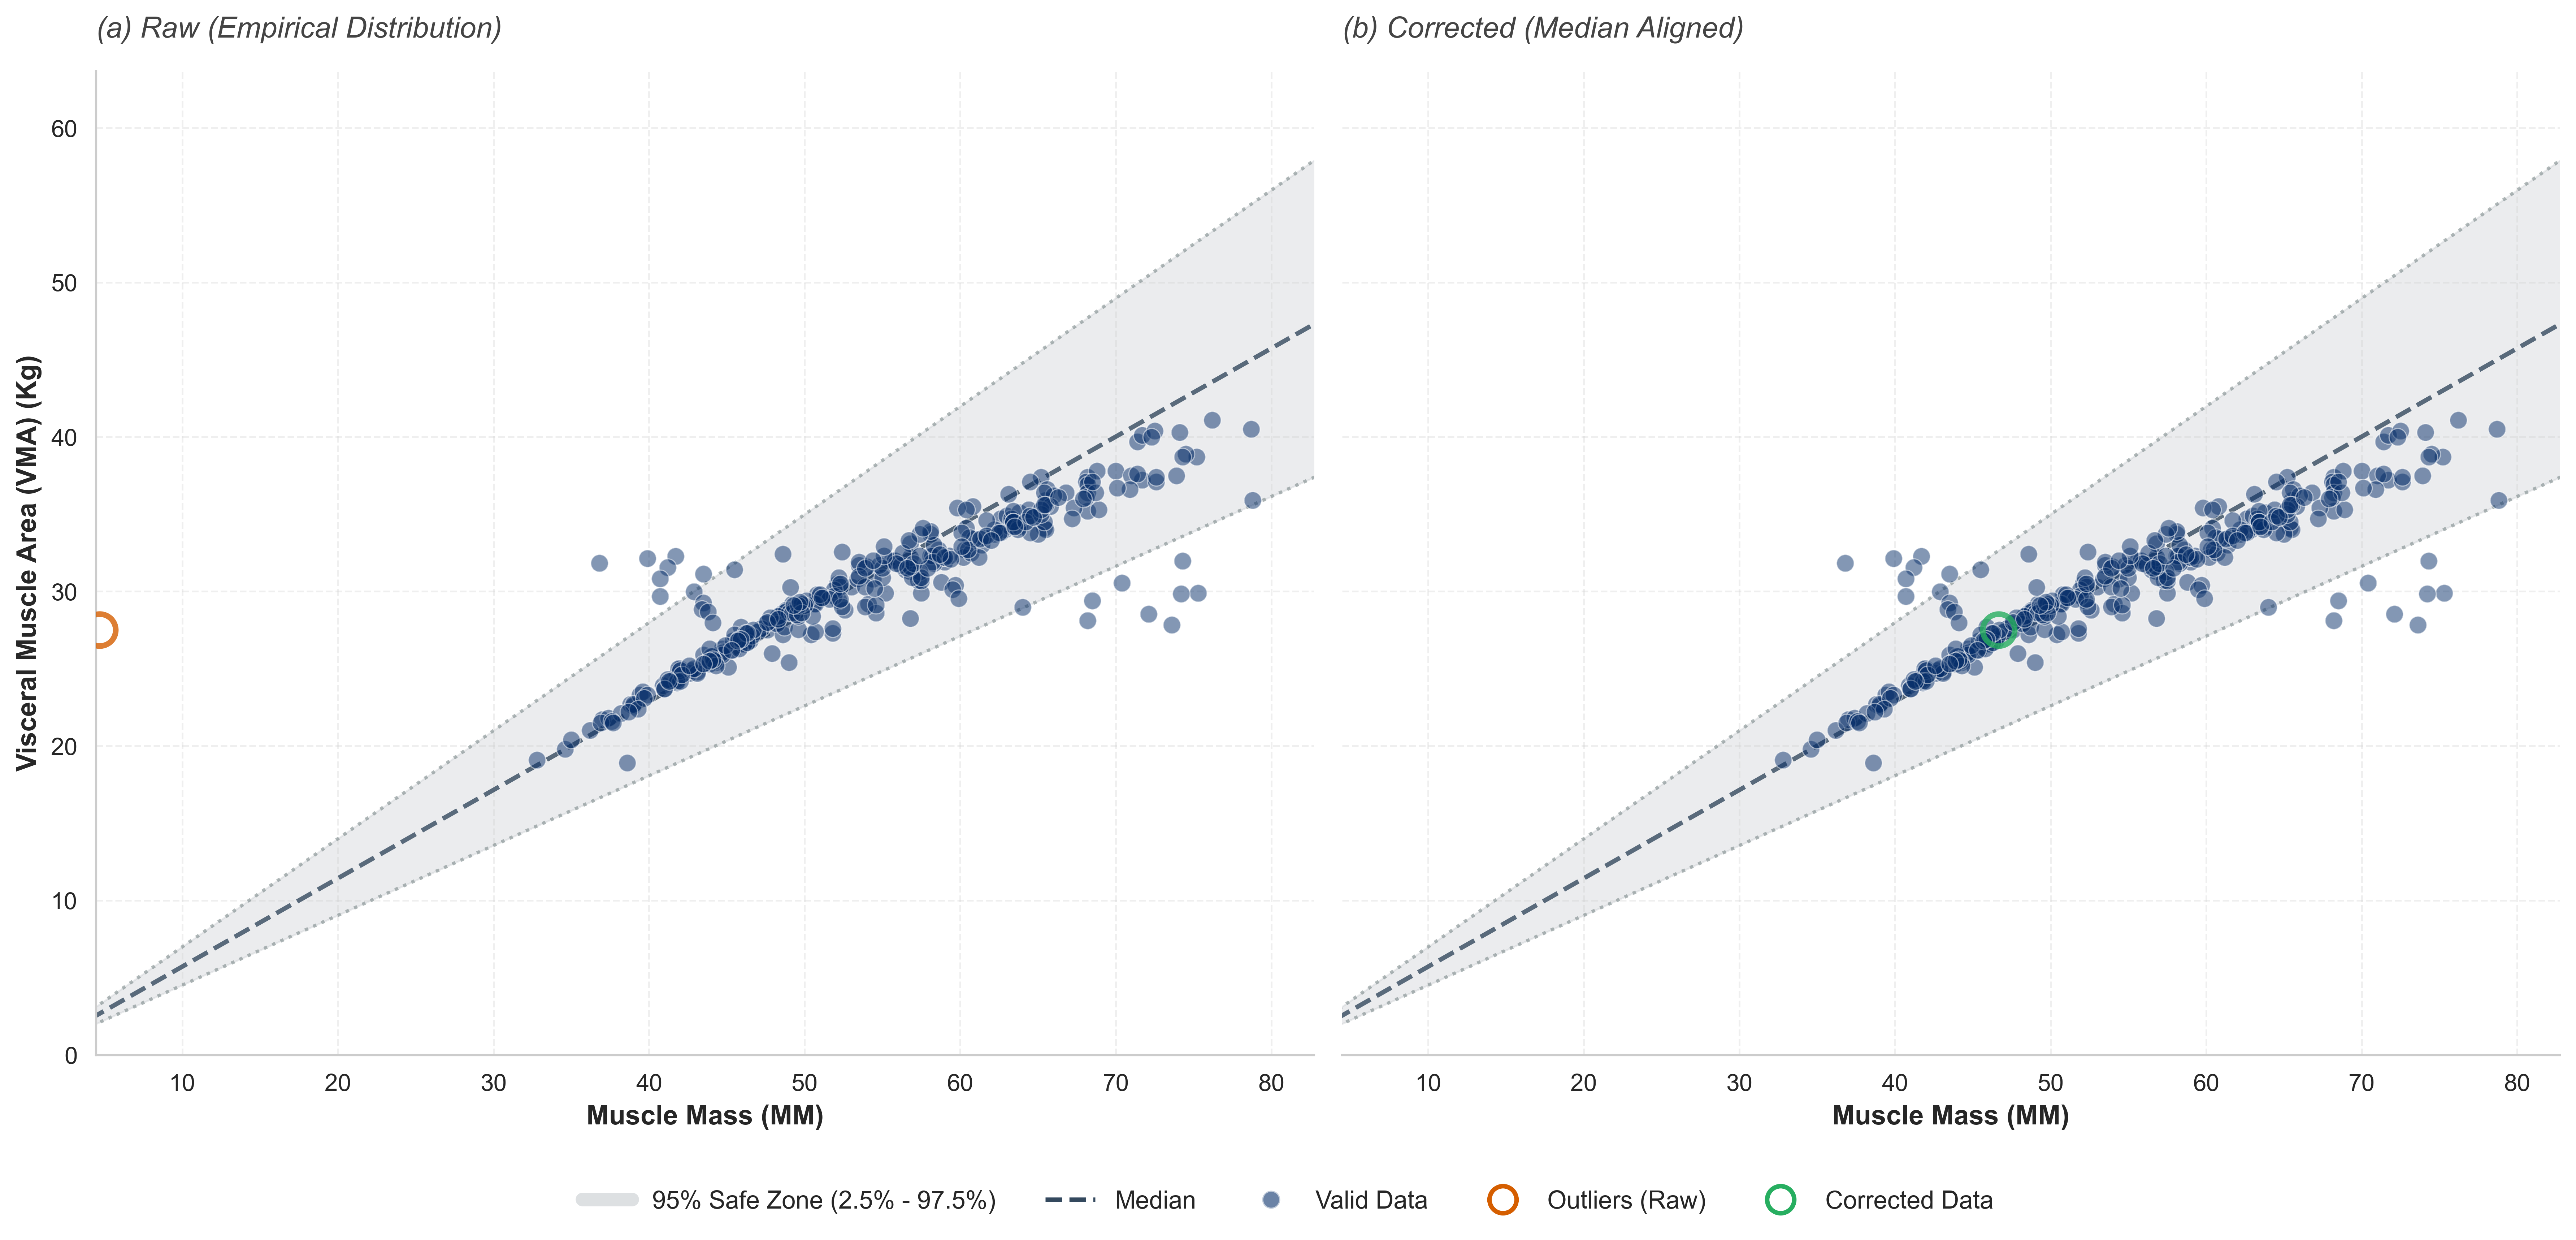

In [16]:
PlottingData.plot_empirical_cone_repair(
    df_raw=df_protein_raw,
    df_fixed=df,
    x_col='Muscle Mass (MM)',
    y_col='Visceral Muscle Area (VMA) (Kg)',
    main_title="Muscle Fixed",
    title_on  = False,
    is_final_record= True
)

[I/O Trace] Figure exported successfully: C:\Users\yqn1e23\PycharmProjects\COMP3200_Individual_Project\Storage\Figure\Data Figure\4C_Bland_Altman_.png


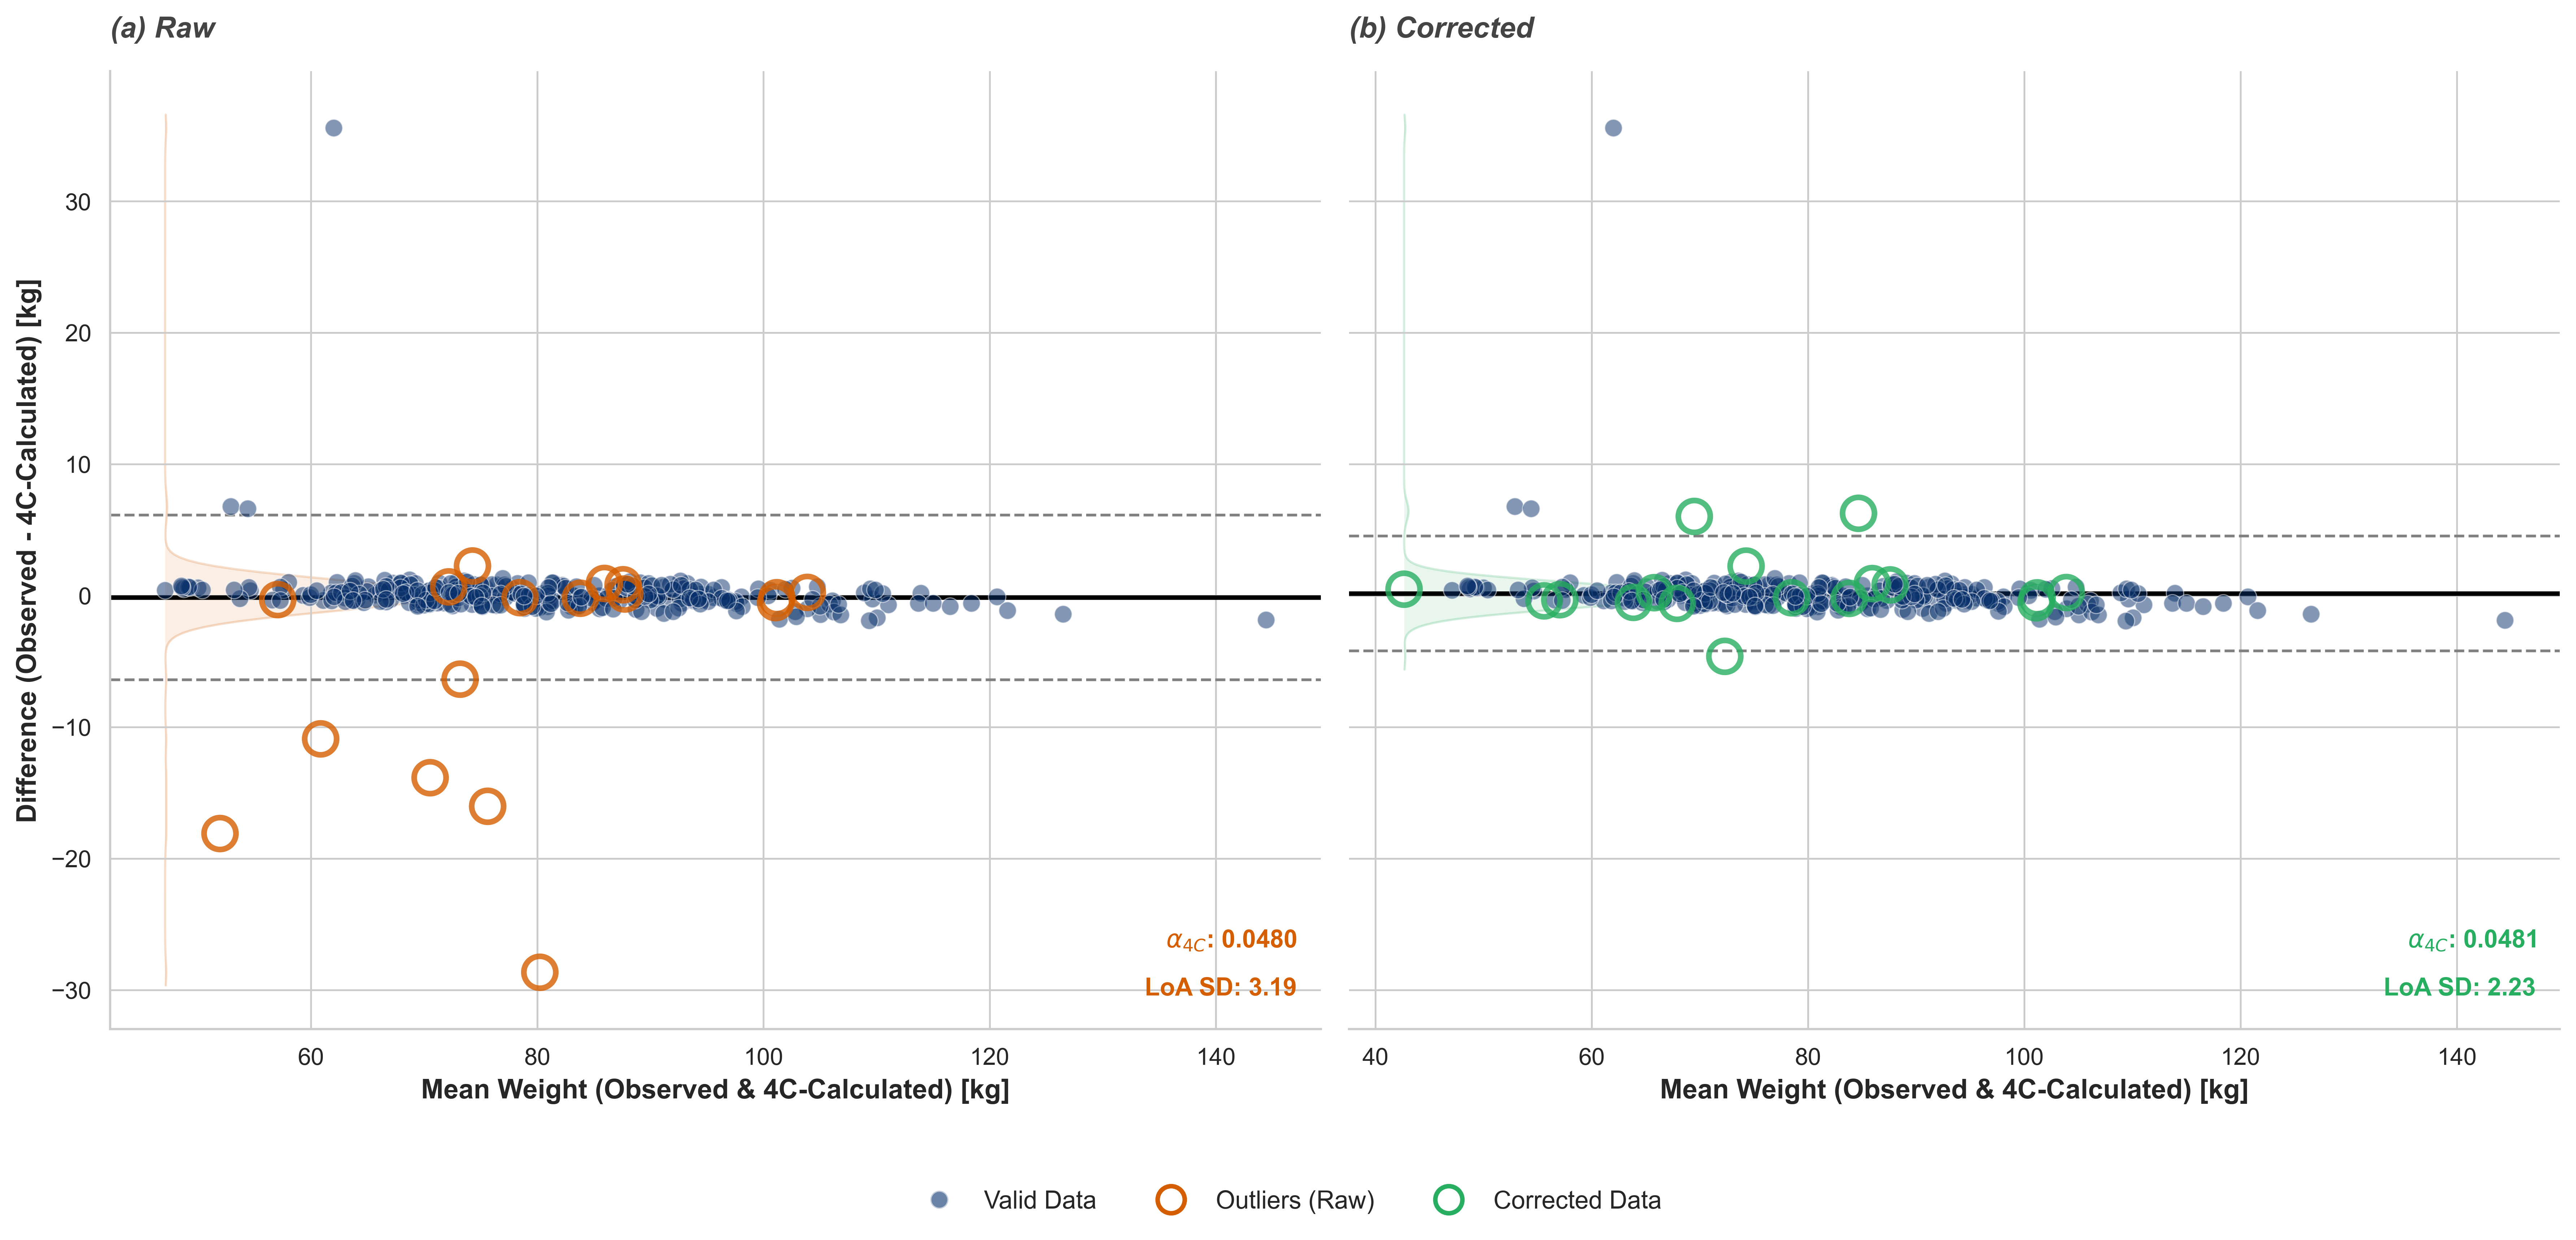

In [17]:
PlottingData.plot_4c_weight_bland_altman(
    df_raw,df,
    main_title="4C Bland Altman",
    title_on  = False,
    is_final_record= True)